#  Objectif :
>
> 1. Construire une matrice BoW (Bag-of-Words) pour un corpus de 37 textes.
> 2. Calculer la matrice des distances entre tous les textes.
> 3. Calculer, pour chaque texte, la distance au **centroïde** (moyenne) de chaque **genre** (ex. *Aventure*, *Récit de voyage*, *Amour*).
> 4. **Bonus** : visualiser les distances (heatmap, MDS/TSNE).
>## 📦 Pré-requis

* Python ≥ 3.9
* `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `unidecode` (facultatif)
* Arborescence (adapter `CORPUS_DIR` si besoin) :

```
~/Documents/cours/2025/TALL_CPES_25-26/seance_04/TD/corpus/*.txt



```



## 🗂️ 0. Imports & paramètres


In [2]:
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.0 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 11.7 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 17.0 MB/s eta 0:00:00m eta 0:00:010:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, glob, re, json, textwrap
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt

# (Optionnel) pour normaliser les accents dans les tokens
try:
    from unidecode import unidecode
    USE_UNIDECODE = True
except Exception:
    USE_UNIDECODE = False

In [38]:

#CORPUS_DIR = Path.home() / "Documents/cours/2025/TALL_CPES_25-26/seance_04/TD/corpus"
CORPUS_DIR = "corpus/"


# --- Paramètres BoW
MAX_FEATURES = 1000     # nb max de mots (les plus fréquents)
MIN_DF = 5              # mot conservé s'il apparaît dans >= MIN_DF documents
STOP_LANG = "english"    # stopwords intégrés de scikit-learn ("french", None, etc.)
LOWERCASE = True
NGRAM_RANGE = (1, 1)    # unigrams; vous pouvez tester (1,2)

## 📥 1. Charger les textes

> On lit tous les `.txt` du dossier, en gérant au mieux l’encodage.


In [ ]:
type(CORPUS_DIR)

In [41]:
paths = sorted(glob.glob(str(CORPUS_DIR+"*.txt")))

In [42]:
paths

['corpus/1900_Verne-Jules-_Seconde-patrie.txt',
 'corpus/1901_Thurner-Georges_Mademoiselle-Flammette.txt',
 'corpus/1902_Allais-Alphonse_Le-Captain-Cap.txt',
 'corpus/1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-I.txt',
 'corpus/1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-II.txt',
 'corpus/1902_Loti-Pierre_Les-derniers-jours-de-Pekin.txt',
 'corpus/1903_Loti-Pierre_L-Inde-(sans-les-Anglais).txt',
 'corpus/1903_Vogue-Eugene-Melchior-de_Le-Maitre-de-la-mer.txt',
 'corpus/1904_Le-Rouge-Gustave_L-Esclave-amoureuse.txt',
 'corpus/1904_Loti-Pierre_Vers-Ispahan.txt',
 'corpus/1905_Farrere-Claude_Les-civilises.txt',
 'corpus/1905_Le-Rouge-Gustave_L-Espionne-du-grand-Lama.txt',
 'corpus/1905_Lermina-Jules_To-Ho-Le-Tueur-d-or.txt',
 'corpus/1905_Verne-Jules_L-invasion-de-la-mer.txt',
 'corpus/1905_Verne-Jules_Le-Phare-du-Bout-du-Monde.txt',
 'corpus/1906_Gide-Andre_Amyntas.txt',
 "corpus/1908_Delly_L'exilee.txt",
 'corpus/1908_Veuzit-Max-du_Le-mystere-de-Malbackt.txt',
 'corpus/1911_Gau

In [44]:
# 1) Load corpus files
paths = sorted(glob.glob(str(CORPUS_DIR+"*.txt")))
def read_text(path):
    # essai multiprotocole d'encodage
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            with open(path, "r", encoding=enc, errors="ignore") as f:
                content = f.read()
            return content
        except Exception:
            continue
    raise IOError(f"Cannot read {path} with common encodings.")

docs = [read_text(p) for p in paths]
filenames = [os.path.basename(p) for p in paths]



In [49]:
filenames[0]

'1900_Verne-Jules-_Seconde-patrie.txt'

In [51]:
docs[0]

'La belle saison arriva dès la seconde semaine d’octobre. Ce mois est le premier du printemps\xa0de la zone méridionale. L’hiver n’avait pas été très rigoureux sous cette latitude du dix-neuvième degré entre l’Équateur et le tropique du Capricorne. Les hôtes de la Nouvelle-Suisse allaient pouvoir reprendre leurs travaux accoutumés.Après onze ans passés sur cette terre, ce n’était pas trop tôt de chercher à reconnaître si elle appartenait à l’un des continents que baigne l’océan Indien, ou si les géographes devaient la comprendre parmi les îles de ces parages.Sans doute, depuis que la jeune Anglaise avait été recueillie par Fritz sur la Roche-Fumante, M. Zermatt, sa femme, ses quatre fils et Jenny Montrose étaient aussi heureux qu’on peut l’être. Il est vrai, les craintes de l’avenir et ses chances si improbables que le salut vînt du dehors, le souvenir du pays, le besoin de reprendre contact avec l’humanité, se faisaient parfois sentir, et n’est-ce pas une loi de nature qui s’impose à 

In [45]:
len(paths), filenames[:5]

(37,
 ['1900_Verne-Jules-_Seconde-patrie.txt',
  '1901_Thurner-Georges_Mademoiselle-Flammette.txt',
  '1902_Allais-Alphonse_Le-Captain-Cap.txt',
  '1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-I.txt',
  '1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-II.txt'])

# 2) Genre mapping (à adapter)

In [53]:

CSV_PATH = ''#CORPUS_DIR.parent / "genres.csv"  # placez un CSV à ../genres.csv si vous préférez

if CSV_PATH.exists():
    df_genres = pd.read_csv(CSV_PATH)  # colonnes: filename, genre
else:
    # Exemple: complétez ce dictionnaire pendant le TP
    manual_map = {
        # "1900_Verne-Jules-_Seconde-patrie.txt": "Aventure",
        # "1963_Bouvier-Nicolas_L-usage-du-monde.txt": "Récit de voyage",
        # "1932_Veuzit-Max-du_Petite-comtesse.txt": "Amour",
        # ...
    }
    df_genres = pd.DataFrame({
        "filename": filenames,
        "genre": [manual_map.get(fn, "Inconnu") for fn in filenames]
    })

# Sécurise l'ordre (aligné aux fichiers lus)
df_genres = df_genres.set_index("filename").loc[filenames].reset_index()
genres = df_genres["genre"].values
unique_genres = sorted(pd.unique(genres))
display(df_genres.head())
print("Genres:", unique_genres)


AttributeError: 'str' object has no attribute 'exists'


## 🧱 3. Fonctions utilitaires : distances & BoW

> Nous vous **donnons** ci-dessous :
>
> * des définitions simples des **distances** (Cosine & Euclidienne)
> * une fonction pour construire le **DataFrame BoW** : N lignes = N romans ; M colonnes = M mots.


In [54]:
# 3) Regex tokenizer

TOKEN_REGEX = re.compile(r"[A-Za-zÀ-ÖØ-öø-ÿ]+(?:[-'][A-Za-zÀ-ÖØ-öø-ÿ]+)*")

def regex_tokenizer(text: str, lower: bool = True):
    if lower:
        text = text.lower()
    return TOKEN_REGEX.findall(text)


In [55]:
# 4) BoW avec le tokenizer regex 

def build_relfreq_dataframe_regex(texts,
                                  max_features=MAX_FEATURES,
                                  min_df=MIN_DF,
                                  stop_lang=STOP_LANG,
                                  ngram_range=NGRAM_RANGE):
    """
    Retourne:
      - df_relfreq: DataFrame (n_docs x n_terms) avec f_ij / sum_j f_ij
      - vectorizer: CountVectorizer entraîné
      - row_lengths: longueurs (somme des comptes) par doc (après tokenisation/stopwords)
    """
    vectorizer = CountVectorizer(
        tokenizer=lambda s: regex_tokenizer(s, lower=True),
        token_pattern=None,            # IMPORTANT: sinon le tokenizer custom est ignoré
        preprocessor=None,
        lowercase=False,               # déjà fait dans tokenizer
        strip_accents="unicode",       # normalise les accents
        stop_words=stop_lang,
        max_features=max_features,
        min_df=min_df,
        ngram_range=ngram_range
    )
    X = vectorizer.fit_transform(texts)            # sparse counts
    vocab = vectorizer.get_feature_names_out()
    counts = X.toarray().astype(float)             # dense pour la normalisation

    row_sums = counts.sum(axis=1, keepdims=True)   # longueurs après filtrage
    # Sécurité: éviter division par zéro (document vide après stopwords)
    zero_rows = (row_sums == 0).flatten()
    if np.any(zero_rows):
        # On laisse ces lignes à zéro; cosine_distance échouera si vecteur nul
        # mais c'est informatif pour les étudiants
        print(f"Attention: {zero_rows.sum()} document(s) avec longueur 0 après filtrage.")

    relfreq = np.divide(counts, row_sums, where=row_sums!=0)

    df_relfreq = pd.DataFrame(relfreq, index=filenames, columns=vocab)
    return df_relfreq, vectorizer, row_sums.flatten()

> 💡 *Remarque* : `strip_accents="unicode"` suffit en général. Si vous préférez un contrôle fin, vous pouvez pré-nettoyer avec `unidecode` avant vectorisation.
>
## 🧮 4. Construire la matrice BoW


In [97]:

df_bow, vect, tmp = build_relfreq_dataframe_regex(docs)
df_bow.iloc[:5, :10]



,a-t-il,abord,absolument,affaire,affaires,affection,afin,age,ah,ai
1900_Verne-Jules-_Seconde-patrie.txt,0.000216,0.000599,0.000168,0.000108,0.000072,0.000108,0.000863,0.000228,0.000288,0.000695
1901_Thurner-Georges_Mademoiselle-Flammette.txt,0.000231,0.000333,0.000308,0.000231,0.000282,0.000308,0.000385,0.000205,0.001667,0.004026
1902_Allais-Alphonse_Le-Captain-Cap.txt,0.000042,0.000292,0.000042,0.000376,0.000083,0.000000,0.000209,0.000250,0.001753,0.003423
1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-I.txt,0.000208,0.000976,0.000353,0.000125,0.000125,0.000145,0.000208,0.000436,0.000145,0.002741
1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-II.txt,0.000124,0.000577,0.000351,0.000165,0.000082,0.000000,0.000103,0.000082,0.000186,0.001217


In [93]:
genres = ["aventures", "sentimental", "aventures", "aventures", "aventures", "voyages", "voyages", "aventures", "aventures", "voyages", "aventures", "aventures", "aventures", "aventures", "aventures", "voyages", "sentimental", "sentimental", "voyages","voyages","voyages", "sentimental","sentimental","aventures", "sentimental","sentimental","sentimental","sentimental","sentimental","sentimental","sentimental","voyages","sentimental", "voyages",  "voyages","voyages","voyages"]

In [94]:
df_bow["genre"] = genres

In [96]:
df_bow[df_bow["genre"] == "voyages"]

,a-t-il,abord,absolument,affaire,affaires,affection,afin,age,ah,ai,...,voyant,voyez,voyons,vrai,vraiment,vu,vue,y,yeux,genre
1902_Loti-Pierre_Les-derniers-jours-de-Pekin.txt,0.000000,0.001042,0.000045,0.000023,0.000000,0.000000,0.000294,0.000204,0.000068,0.000838,...,0.000000,0.000000,0.000113,0.000317,0.000475,0.000475,0.000566,0.006023,0.001449,voyages
1903_Loti-Pierre_L-Inde-(sans-les-Anglais).txt,0.000000,0.001010,0.000124,0.000000,0.000000,0.000000,0.000160,0.000230,0.000106,0.001081,...,0.000018,0.000018,0.000018,0.000425,0.000390,0.000372,0.000425,0.006009,0.002322,voyages
1904_Loti-Pierre_Vers-Ispahan.txt,0.000132,0.000903,0.000110,0.000044,0.000044,0.000000,0.000154,0.000176,0.000022,0.000683,...,0.000066,0.000000,0.000088,0.000264,0.000529,0.000419,0.000727,0.005641,0.001520,voyages
1906_Gide-Andre_Amyntas.txt,0.000162,0.000915,0.000000,0.000000,0.000000,0.000000,0.000108,0.000162,0.001454,0.003661,...,0.000000,0.000000,0.000000,0.000215,0.000162,0.000808,0.000377,0.007000,0.000862,voyages
1911_Gautier-Judith_En-chine-Merveilleuses-histoires.txt,0.000106,0.000000,0.000106,0.000000,0.000000,0.000106,0.000317,0.000000,0.000000,0.000211,...,0.000000,0.000000,0.000211,0.000317,0.000528,0.000317,0.000528,0.003591,0.001796,voyages
1912_Loti-Pierre_Un-pelerin-d-Angkor 2.txt,0.000000,0.000885,0.000059,0.000000,0.000000,0.000000,0.000177,0.000177,0.000354,0.002006,...,0.000000,0.000000,0.000413,0.000295,0.000236,0.000649,0.000531,0.007082,0.001652,voyages
1912_Loti-Pierre_Un-pelerin-d-Angkor.txt,0.000000,0.000885,0.000059,0.000000,0.000000,0.000000,0.000177,0.000177,0.000354,0.002006,...,0.000000,0.000000,0.000413,0.000295,0.000236,0.000649,0.000531,0.007082,0.001652,voyages
1938_Larbaud-Valery_Aux-couleurs-de-Rome.txt,0.000205,0.000000,0.000000,0.000369,0.000287,0.000041,0.000041,0.000287,0.000574,0.000533,...,0.000164,0.000082,0.000082,0.000451,0.000492,0.000533,0.000492,0.003319,0.001147,voyages
1963_Bouvier-Nicolas_L-usage-du-monde.txt,0.000016,0.000300,0.000158,0.000648,0.000332,0.000016,0.000000,0.000253,0.000142,0.001233,...,0.000032,0.000063,0.000016,0.000206,0.000237,0.000364,0.000316,0.004995,0.001391,voyages
2008_Rolin-Olivier_La-Chambre-des-cartes.txt,0.000077,0.000774,0.000077,0.000155,0.000077,0.000000,0.000155,0.000155,0.000851,0.001934,...,0.000077,0.000232,0.000000,0.000387,0.000309,0.000928,0.000774,0.010134,0.000851,voyages


## 📏 5. Matrice des distances entre textes

> Choisissez une métrique : **cosine** (recommandée pour du texte) ou **euclidienne** (sur BoW bruts).


In [61]:
# 5) Distance functions (exactement comme spécifié)

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def vector_len(v):
    return np.sqrt(np.sum(v ** 2))

def cosine_distance(a, b):
    return 1 - np.dot(a, b) / (vector_len(a) * vector_len(b))

In [60]:
df_bow.head(2)

,a-t-il,abord,absolument,affaire,affaires,affection,afin,age,ah,ai,...,voyait,voyant,voyez,voyons,vrai,vraiment,vu,vue,y,yeux
1900_Verne-Jules-_Seconde-patrie.txt,0.000216,0.000599,0.000168,0.000108,0.000072,0.000108,0.000863,0.000228,0.000288,0.000695,...,0.000204,0.000084,0.000048,0.000132,0.000803,0.000012,0.000132,0.001115,0.006439,0.000492
1901_Thurner-Georges_Mademoiselle-Flammette.txt,0.000231,0.000333,0.000308,0.000231,0.000282,0.000308,0.000385,0.000205,0.001667,0.004026,...,0.000179,0.000564,0.000179,0.000051,0.000359,0.000231,0.000359,0.000641,0.003128,0.001590


In [70]:
def get_distance(BoW_df):
    """
    X_dense: (n_docs, n_feats) dense ndarray
    dist_fn: fonction distance(a, b) -> float
    """
    X = BoW_df.values
    n = len(X)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            d = cosine_distance(X[i], X[j])
            D[i, j] = d
            D[j, i] = d
    return pd.DataFrame(D)

In [71]:
matrix_distances = get_distance(df_bow)

In [73]:
matrix_distances.columns = df_bow.index
matrix_distances.index = df_bow.index

In [137]:
matrix_distances.head()

,1900_Verne-Jules-_Seconde-patrie.txt,1901_Thurner-Georges_Mademoiselle-Flammette.txt,1902_Allais-Alphonse_Le-Captain-Cap.txt,1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-I.txt,1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-II.txt,1902_Loti-Pierre_Les-derniers-jours-de-Pekin.txt,1903_Loti-Pierre_L-Inde-(sans-les-Anglais).txt,1903_Vogue-Eugene-Melchior-de_Le-Maitre-de-la-mer.txt,1904_Le-Rouge-Gustave_L-Esclave-amoureuse.txt,1904_Loti-Pierre_Vers-Ispahan.txt,...,1922_Alanic-Mathilde_La-route-ardente.txt,"1931_Veuzit-Max-du_John,-chauffeur-russe.txt",1932_Veuzit-Max-du_Petite-comtesse.txt,1933_Veuzit-Max-du_Vers-l'unique.txt,1938_Larbaud-Valery_Aux-couleurs-de-Rome.txt,1955_Delly_Ourida.txt,1963_Bouvier-Nicolas_L-usage-du-monde.txt,2008_Rolin-Olivier_La-Chambre-des-cartes.txt,2012_Kerangal-Maylis-de_Tangente-vers-l-est.txt,2013_Tesson-Sylvain_Dans-les-forets-de-Siberie.txt
1900_Verne-Jules-_Seconde-patrie.txt,0.000000,0.085496,0.056930,0.037174,0.032102,0.110826,0.109176,0.062099,0.070600,0.118197,...,0.049436,0.127676,0.119105,0.129387,0.153182,0.078950,0.043426,0.055958,0.066290,0.078027
1901_Thurner-Georges_Mademoiselle-Flammette.txt,0.085496,0.000000,0.090177,0.085208,0.081322,0.186886,0.186274,0.075536,0.083105,0.191574,...,0.064701,0.049686,0.053473,0.056885,0.150636,0.045101,0.102420,0.112558,0.094134,0.148030
1902_Allais-Alphonse_Le-Captain-Cap.txt,0.056930,0.090177,0.000000,0.053459,0.054063,0.107702,0.111342,0.053239,0.083872,0.113568,...,0.060599,0.115583,0.084525,0.109389,0.162528,0.078906,0.056169,0.045234,0.102886,0.087466
1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-I.txt,0.037174,0.085208,0.053459,0.000000,0.005954,0.094890,0.095200,0.039267,0.034899,0.104435,...,0.057321,0.110994,0.109211,0.109767,0.165591,0.070258,0.032082,0.052263,0.067858,0.085463
1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-II.txt,0.032102,0.081322,0.054063,0.005954,0.000000,0.084496,0.086301,0.046626,0.033005,0.093051,...,0.054546,0.116694,0.116939,0.117155,0.140771,0.077945,0.027031,0.053927,0.059232,0.085720


In [98]:
genres = ["aventures", "sentimental", "aventures", "aventures", "aventures", "voyages", "voyages", "aventures", "aventures", "voyages", "aventures", "aventures", "aventures", "aventures", "aventures", "voyages", "sentimental", "sentimental", "voyages","voyages","voyages", "sentimental","sentimental","aventures", "sentimental","sentimental","sentimental","sentimental","sentimental","sentimental","sentimental","voyages","sentimental", "voyages",  "voyages","voyages","voyages"]

In [139]:
def distance_genres(df_freq, genres, dist_fn=cosine_distance):
    """
    Calcule la distance de chaque texte au centroïde de chaque genre, en reprenant
    la structure que vous avez utilisée en classe (création des sous-DataFrames,
    moyennes, puis boucle via iterrows).

    Renvoie un DataFrame (n_docs x 3) avec les colonnes ['voyages','aventures','sentimental'].
    """
    # On travaille sur une copie pour ne pas modifier df_freq en place (vous aviez un drop inplace plus bas)
    df = df_freq.copy()
    df["genres"] = genres

    # Sous-ensembles par genre
    DF_VOYAGE     = df[df["genres"] == "voyages"]
    DF_AVENTURES  = df[df["genres"] == "aventures"]
    DF_SENTIMENTAL= df[df["genres"] == "sentimental"]

    # Centroïdes (= moyenne colonne par colonne)
    MEAN_VOYAGE      = np.mean(DF_VOYAGE.drop(["genres"], axis=1), axis=0)
    MEAN_AVENTURE    = np.mean(DF_AVENTURES.drop(["genres"], axis=1), axis=0)
    MEAN_SENTIMENTAL = np.mean(DF_SENTIMENTAL.drop(["genres"], axis=1), axis=0)

    # ⬇️ Pourquoi .to_numpy(...) ?
    # - Vos fonctions de distance prennent des vecteurs NumPy (1D). Convertir une Series pandas en ndarray
    #   évite tout alignement par index/étiquettes et garantit une simple opération vectorielle sur des floats.
    MV = MEAN_VOYAGE.to_numpy(dtype=float)
    MA = MEAN_AVENTURE.to_numpy(dtype=float)
    MS = MEAN_SENTIMENTAL.to_numpy(dtype=float)

    # On va calculer, pour chaque ligne-document, la distance aux trois centroïdes.
    res = []
    doc_index = df.index
    for _, row in df.drop(columns=["genres"]).iterrows():
        v = row.to_numpy(dtype=float)  # même logique que ci-dessus

        # Sécurité: si un vecteur est nul, la distance cosinus n'est pas définie -> np.nan
        if vector_len(v) == 0:
            dv, da, ds = np.nan, np.nan, np.nan
        else:
            dv = np.nan if vector_len(MV) == 0 else dist_fn(v, MV)
            da = np.nan if vector_len(MA) == 0 else dist_fn(v, MA)
            ds = np.nan if vector_len(MS) == 0 else dist_fn(v, MS)

        res.append([dv, da, ds])

    # On retourne un DataFrame (et non une liste), pour être directement exploitable
    return pd.DataFrame(res, index=doc_index, columns=["voyages", "aventures", "sentimental"])


In [141]:
DF_GENRES_DISTANCES = distance_genres(df_bow, genres)

In [142]:
DF_GENRES_DISTANCES["genres"] = genres

In [143]:
DF_GENRES_DISTANCES

,voyages,aventures,sentimental,genres
1900_Verne-Jules-_Seconde-patrie.txt,0.054669,0.021006,0.087088,aventures
1901_Thurner-Georges_Mademoiselle-Flammette.txt,0.112905,0.054822,0.030193,sentimental
1902_Allais-Alphonse_Le-Captain-Cap.txt,0.060211,0.036255,0.071234,aventures
1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-I.txt,0.051275,0.013558,0.075158,aventures
1902_Le-Rouge-Gustave_La-Princesse-des-airs_Tome-II.txt,0.042219,0.009491,0.078938,aventures
1902_Loti-Pierre_Les-derniers-jours-de-Pekin.txt,0.023148,0.087998,0.187315,voyages
1903_Loti-Pierre_L-Inde-(sans-les-Anglais).txt,0.021663,0.087024,0.182324,voyages
1903_Vogue-Eugene-Melchior-de_Le-Maitre-de-la-mer.txt,0.074642,0.034316,0.054726,aventures
1904_Le-Rouge-Gustave_L-Esclave-amoureuse.txt,0.065520,0.029844,0.067647,aventures
1904_Loti-Pierre_Vers-Ispahan.txt,0.028433,0.097261,0.195289,voyages


## 📊 7. Bonus — Visualisations


# 7.2) Heatmap (matplotlib)
plt.figure(figsize=(8, 7))
plt.imshow(df_D_cos, interpolation="nearest")




In [130]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [147]:
def plot_genre_distance_heatmap(df):
    """
    Heatmap of distances text→genre.
    df: DataFrame with columns ["voyages","aventures","sentimental","genres"]
        index = filenames
    """
    # Data for heatmap
    dist_df = df[["voyages", "aventures", "sentimental"]]

    # Build a palette for the true genres
    genre_labels = df["genres"].unique()
    palette = sns.color_palette("Set2", n_colors=len(genre_labels))
    lut = dict(zip(genre_labels, palette))
    row_colors = df["genres"].map(lut)

    # Plot
    plt.figure(figsize=(10, 12))
    g = sns.heatmap(dist_df, cmap="viridis", cbar_kws={'label': 'Distance'})
    plt.title("Distances des textes aux centroïdes de genres")
    plt.xlabel("Genres cibles")
    plt.ylabel("Textes")

    # Add true labels as colored ticks on the y-axis
    for tick_label, color in zip(g.get_yticklabels(), row_colors):
        tick_label.set_color(color)

    plt.tight_layout()
    plt.savefig("Roman_Distance_Genres.png", dpi=300)
    plt.show()


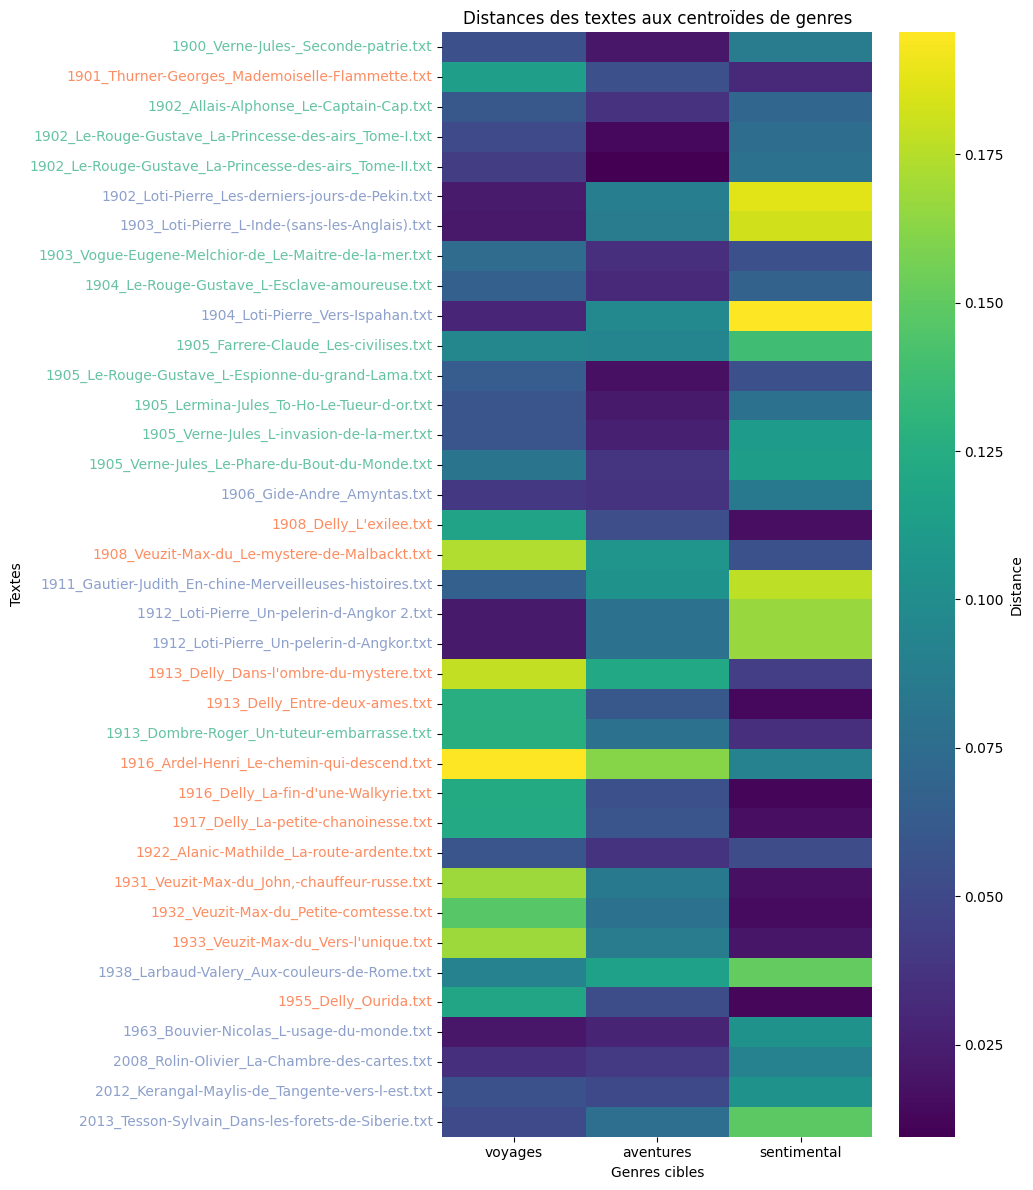

In [148]:
plot_genre_distance_heatmap(DF_GENRES_DISTANCES)